In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy 
from scipy.stats.contingency import chi2_contingency
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from seaborn import heatmap
from sklearn.preprocessing import LabelEncoder

In [3]:
DS = pd.read_csv("instagram_usage_lifestyle.csv")

In [4]:
DS

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,Instagram,61,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,...,2025-01-14,15.8,Videos,Other,Friends only,Yes,Yes,4,Free,0.97
1547892,1547893,Instagram,42,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,...,2025-08-04,38.0,Photos,Art,Private,No,No,1,Premium,1.32
1547893,1547894,Instagram,32,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,...,2025-04-10,31.8,Live,Other,Private,Yes,Yes,5,Free,1.01
1547894,1547895,Instagram,14,Female,Other,Urban,Low,Student,Bachelor’s,Single,...,2025-03-21,23.6,Live,Tech,Private,Yes,No,3,Free,1.11


In [5]:
DS.dtypes

user_id                             int64
app_name                              str
age                                 int64
gender                                str
country                               str
urban_rural                           str
income_level                          str
employment_status                     str
education_level                       str
relationship_status                   str
has_children                          str
exercise_hours_per_week           float64
sleep_hours_per_night             float64
diet_quality                          str
smoking                               str
alcohol_frequency                     str
perceived_stress_score              int64
self_reported_happiness             int64
body_mass_index                   float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
daily_steps_count                   int64
weekly_work_hours                 float64
hobbies_count                     

In [6]:
DS.nunique()

user_id                           1547896
app_name                                1
age                                    53
gender                                  4
country                                10
urban_rural                             3
income_level                            5
employment_status                       6
education_level                         6
relationship_status                     5
has_children                            2
exercise_hours_per_week               241
sleep_hours_per_night                  71
diet_quality                            5
smoking                                 3
alcohol_frequency                       5
perceived_stress_score                 41
self_reported_happiness                10
body_mass_index                       286
blood_pressure_systolic                70
blood_pressure_diastolic               40
daily_steps_count                     773
weekly_work_hours                     800
hobbies_count                     

<Axes: >

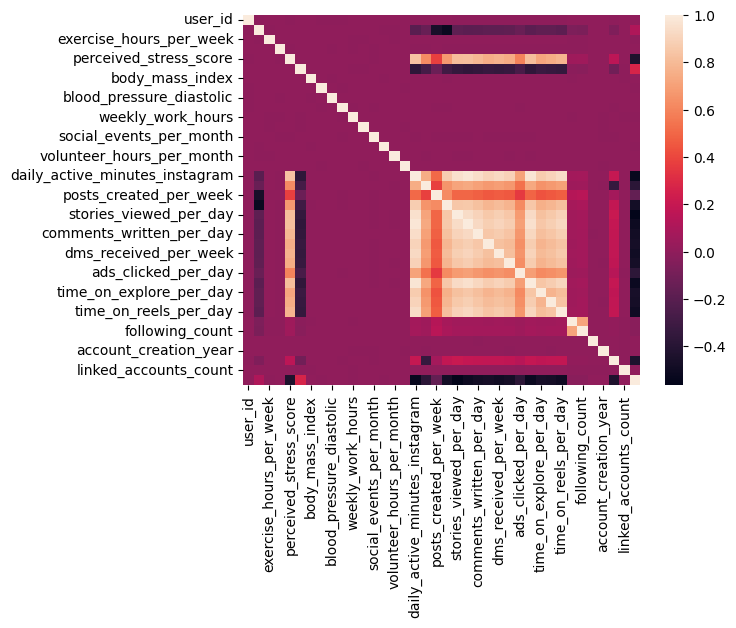

In [7]:
correlations = DS.corr(numeric_only = True)
heatmap(correlations)

In [8]:
cat_cols = []
for column in DS.columns:
    if DS[column].dtype == "str":
        cat_cols.append(column)
    else:
        continue
cat_cols

['app_name',
 'gender',
 'country',
 'urban_rural',
 'income_level',
 'employment_status',
 'education_level',
 'relationship_status',
 'has_children',
 'diet_quality',
 'smoking',
 'alcohol_frequency',
 'uses_premium_features',
 'last_login_date',
 'content_type_preference',
 'preferred_content_theme',
 'privacy_setting_level',
 'two_factor_auth_enabled',
 'biometric_login_used',
 'subscription_status']

In [9]:
cat_cols.pop(5)

'employment_status'

In [10]:
chi2_contingency(pd.crosstab(DS["employment_status"],DS["gender"]))

Chi2ContingencyResult(statistic=np.float64(17.67324645607454), pvalue=np.float64(0.2802333531014224), dof=15, expected_freq=array([[ 89421.17655837,  89459.93772837,   5560.90375581,
          1887.98195744],
       [333719.56216761, 333864.21873756,  20753.27610382,
          7045.942991  ],
       [ 59404.87800731,  59430.62808871,   3694.25701985,
          1254.23688413],
       [ 22370.41122789,  22380.10807315,   1391.16603699,
           472.31466197],
       [163305.82561232, 163376.61337325,  10155.62547871,
          3447.93553572],
       [ 74625.1464265 ,  74657.49399895,   4640.77160481,
          1575.58796973]]))

In [10]:
cat_cols

['app_name',
 'gender',
 'country',
 'urban_rural',
 'income_level',
 'education_level',
 'relationship_status',
 'has_children',
 'diet_quality',
 'smoking',
 'alcohol_frequency',
 'uses_premium_features',
 'last_login_date',
 'content_type_preference',
 'preferred_content_theme',
 'privacy_setting_level',
 'two_factor_auth_enabled',
 'biometric_login_used',
 'subscription_status']

In [11]:
for i in cat_cols:
    res = chi2_contingency(pd.crosstab(DS["employment_status"],DS[i]))
    print(f"{i} and employment status: {res.pvalue}")

app_name and employment status: 1.0
gender and employment status: 0.2802333531014224
country and employment status: 0.6667742624292347
urban_rural and employment status: 0.8457046883191868
income_level and employment status: 0.36928970736818595
education_level and employment status: 0.23377123746812686
relationship_status and employment status: 0.7823301734564211
has_children and employment status: 0.9948550732037548
diet_quality and employment status: 0.6534703579276118
smoking and employment status: 0.6213216273999757
alcohol_frequency and employment status: 0.18543878933083224
uses_premium_features and employment status: 0.6786419882838237
last_login_date and employment status: 0.16308194123027225
content_type_preference and employment status: 0.5558438727170759
preferred_content_theme and employment status: 0.40742348395519934
privacy_setting_level and employment status: 0.6743917307190882
two_factor_auth_enabled and employment status: 0.2396104444907568
biometric_login_used and em

In [11]:
#gender and employment status
#alcohol-frequency and emplyment status
#education_level and employment status
#last_login_date and employment status
#subscription_status and employment status
#These are the four columns that relate to Employment Status the most